# Probabilistic shielding training comparison

This demo supports the tutorial section after the **probabilistic shielding algorithms and guarantees**.

The notebook is designed to be run from inside the MASA repository. It trains three MiniPacman variants and then loads the resulting TensorBoard event files to compare reward and safety curves:

1. **Plain PPO** on MiniPacman with the PCTL/CMDP safety signal logged but not hard-shielded;
2. **Model-free RECREG** as a tabular safety-aware baseline;
3. **Probabilistic Shielding + continuous v1 wrapper + ParameterizedPPO**.

The default training budgets are intentionally small so that the notebook can run during a tutorial. Increase `TOTAL_TIMESTEPS` and `EVAL_EPISODES` for smoother curves.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import inspect
import textwrap
import warnings
import pprint

# Make the notebook runnable when dropped into MASA-Safe-RL/tutorial/ or opened from repo root.
HERE = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "masa").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find a parent directory containing the `masa/` package. "
        "Open this notebook from within the MASA-Safe-RL repository, or install MASA with `pip install -e .`."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Using MASA source tree: {REPO_ROOT}")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Importing masa.envs registers environments with MASA's registry.
import masa.envs  # noqa: F401
import masa.common.constraints  # noqa: F401
from masa.common.utils import make_env


def show_source(obj, title: str | None = None, fallback: str | None = None):
    """Display Python source for a function/class in a Markdown code block."""
    if title:
        display(Markdown(f"**{title}**"))
    try:
        src = inspect.getsource(obj)
    except Exception as exc:
        src = fallback or f"# Source unavailable for {obj!r}: {exc}"
    display(Markdown("```python\n" + textwrap.dedent(src).strip() + "\n```"))


def unwrap_chain(env, limit: int = 30):
    cur = env
    seen = []
    for _ in range(limit):
        seen.append(cur)
        nxt = getattr(cur, "env", None)
        if nxt is None or nxt is cur:
            break
        cur = nxt
    return seen


def render_frame(env):
    """Render the first usable RGB frame found while unwrapping env wrappers."""
    for cur in unwrap_chain(env):
        try:
            frame = cur.render()
            if frame is not None and not isinstance(frame, str):
                return frame
        except Exception:
            pass
    return None


def show_frames(frames, titles=None, max_cols: int = 4):
    frames = [f for f in frames if f is not None]
    if not frames:
        print("No RGB frames were captured. Try creating the env with render_mode='rgb_array'.")
        return
    n = len(frames)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(frames[i])
            if titles and i < len(titles):
                ax.set_title(str(titles[i]))
    plt.tight_layout()
    plt.show()


def nested_get(d, *keys, default=None):
    cur = d
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def compact_info(info):
    """Return a compact dict with the most useful MASA wrapper signals."""
    out = {}
    for key in ["labels", "label", "constraint", "reward", "automaton_state", "margin_penalty", "proj_penalty"]:
        if isinstance(info, dict) and key in info:
            out[key] = info[key]
    step = nested_get(info, "constraint", "step", default=None)
    episode = nested_get(info, "constraint", "episode", default=None)
    if step is not None:
        out["constraint.step"] = step
    if episode is not None:
        out["constraint.episode"] = episode
    return out

Using MASA source tree: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL


In [2]:
from datetime import datetime
import os
import shutil
import subprocess
import time
from collections import defaultdict

from masa.envs.tabular.mini_pacman import label_fn as pacman_label_fn, cost_fn as pacman_cost_fn

RUN_DIR = REPO_ROOT / "runs" / "tutorial_prob_shielding"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("TensorBoard / run directory:", RUN_DIR)

SEED = 0
MAX_EPISODE_STEPS = 100
TOTAL_TIMESTEPS = 300_000      # increase for a real comparison#
LOG_FREQ = 10_000
EVAL_EPISODES = 5
SAFETY_PROB = 0.05
HORIZON = 10

Computing successor states and probabilities ... 


100%|█████████████████████████████████████████████████████████████████████████████| 9248/9248 [00:03<00:00, 2400.56it/s]

TensorBoard / run directory: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL/runs/tutorial_prob_shielding


## Environment builders

`ProbShieldWrapperCont` augments a discrete-action environment with a continuous risk-allocation action component. `ParameterizedPPO` is used because ordinary PPO does not know how to parameterize the resulting `Dict({'multi_discrete', 'box'})` action space.

In [49]:
def make_base_minipacman(max_episode_steps: int = MAX_EPISODE_STEPS, seed: int | None = None):
    env = make_env(
        "MiniPacman",
        "PCTL",
        max_episode_steps,
        label_fn=pacman_label_fn,
        constraint_kwargs={"cost_fn": pacman_cost_fn, "alpha": SAFETY_PROB},
        env_kwargs={"render_mode": "rgb_array"},
    )
    if seed is not None:
        env.reset(seed=seed)
    return env


def make_plain_ppo_env():
    return make_base_minipacman()


def make_recreg_env():
    return make_base_minipacman()


def make_cmdp_env(max_episode_steps: int = MAX_EPISODE_STEPS, seed: int | None = None):
    env = make_env(
        "MiniPacman",
        "CMDP",
        max_episode_steps,
        label_fn=pacman_label_fn,
        constraint_kwargs={"cost_fn": pacman_cost_fn, "cost_budget": SAFETY_PROB},
        env_kwargs={"render_mode": "rgb_array"},
    )
    if seed is not None:
        env.reset(seed=seed)
    return env


def make_ppo_lag_env():
    return make_cmdp_env()


def make_cpo_env():
    return make_cmdp_env()


def make_prob_shield_env():
    from masa.prob_shield.prob_shield_wrapper_v1 import ProbShieldWrapperCont
    base_env = make_base_minipacman()
    return ProbShieldWrapperCont(
        base_env,
        label_fn=pacman_label_fn,
        cost_fn=pacman_cost_fn,
        init_safety_bound=SAFETY_PROB,
        theta=1e-10,
        max_vi_steps=10_000,
    )

# Smoke-test environments.
for name, fn in [
    ("plain", make_plain_ppo_env),
    ("recreg", make_recreg_env),
    ("prob_shield", make_prob_shield_env),
]:
    try:
        env = fn()
        obs, info = env.reset(seed=SEED)
        print(f"{name}: observation_space={env.observation_space}; action_space={env.action_space}")
        print(f"{name}: initial obs type={type(obs)}; info={compact_info(info)}")
        env.close()
    except Exception as exc:
        print(f"{name}: smoke test failed: {type(exc).__name__}: {exc}")

plain: observation_space=Discrete(9248); action_space=Discrete(5)
plain: initial obs type=<class 'int'>; info={'labels': set(), 'constraint': {'type': 'PCTL', 'step': {'cost': 0.0, 'violation': 0.0}}, 'constraint.step': {'cost': 0.0, 'violation': 0.0}}
recreg: observation_space=Discrete(9248); action_space=Discrete(5)
recreg: initial obs type=<class 'int'>; info={'labels': set(), 'constraint': {'type': 'PCTL', 'step': {'cost': 0.0, 'violation': 0.0}}, 'constraint.step': {'cost': 0.0, 'violation': 0.0}}
Calculating the maximum number of successor states ...
Calculated maximum number of successor states [12] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...
Initializing value iteration ...
Completed value iteration ...
Initial state lower bound: 0.0
prob_shield: observation_space=Dict('orig_obs': Discrete(9248), 'safety_bound': Box(0.0, 1.0, (1,), float32)); action_space=Dict('box': Box(0.0, 1.0, (12,), float32), 'multi_discrete': MultiDiscrete(

## Training helpers

The code below first tries the direct Python API. MASA is still evolving, so if your local branch has different constructor arguments, the helper prints the exception and writes a runnable CLI-style command stub for you to adapt.

In [44]:
def train_algorithm(label: str, algo_cls, env_fn, algo_kwargs=None, train_kwargs=None):
    """Try to train a MASA algorithm with a small set of common constructor/train signatures."""
    algo_kwargs = dict(algo_kwargs or {})
    train_kwargs = dict(train_kwargs or {})
    log_dir = RUN_DIR / label
    log_dir.mkdir(parents=True, exist_ok=True)

    env = env_fn()
    print(f"\n=== Training {label} ===")
    print("log_dir:", log_dir)
    print("obs space:", env.observation_space)
    print("act space:", env.action_space)

    model=algo_cls(
        env,
        tensorboard_logdir=str(log_dir),
        seed=SEED,
        verbose=1,
        **algo_kwargs
    )

    model.train(
        num_frames=TOTAL_TIMESTEPS,
        eval_freq=0,
        log_freq=LOG_FREQ,
        **train_kwargs
    )
    return model

In [45]:
# Imports are placed here so the notebook fails late and clearly if an optional dependency is missing.
try:
    from masa.algorithms.on_policy import PPO
except Exception:
    from masa.algorithms.on_policy.ppo import PPO

from masa.algorithms.tabular.recreg import RECREG

from masa.prob_shield.parameterized_ppo import ParameterizedPPO

try:
    from masa.algorithms.on_policy import PPOLag
except Exception:
    from masa.algorithms.on_policy.ppo_lag import PPOLag

try:
    from masa.algorithms.on_policy import CPO
except Exception:
    from masa.algorithms.on_policy.cpo import CPO

In [6]:
# Plain PPO baseline.
plain_model = train_algorithm(
    "ppo",
    PPO,
    make_plain_ppo_env,
    algo_kwargs={
        # Add/adjust PPO kwargs for your local MASA branch here.
    },
)


=== Training ppo ===
log_dir: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL/runs/tutorial_prob_shielding/ppo
obs space: Discrete(9248)
act space: Discrete(5)


frames:   0%|                                                                                | 0/300000 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

...

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

------------------------------------
|  run/               |            |
|    fps              |  666.1     |
|    time_elapsed     |  452       |
|    total_timesteps  |  301056    |
------------------------------------
|  train/rollout/     |            |
|    cum_unsafe       |  10.97     |
|    satisfied        |  0.09      |
|    ep_reward        |  0.98      |
|    ep_length        |  94.01     |
------------------------------------
|  train/stats/       |            |
|    policy_loss      |  -0.04968  |
|    value_loss       |  0.001169  |
|    clip_range       |  0.2       |
|    lr               |  0.0003    |
------------------------------------



In [7]:
# Model-free RECREG baseline.
recreg_model = train_algorithm(
    "model_free_recreg",
    RECREG,
    make_recreg_env,
    algo_kwargs={
        "mode": "model_free",
        "horizon": HORIZON,
        "safety_prob": SAFETY_PROB,
    },
)



=== Training model_free_recreg ===
log_dir: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL/runs/tutorial_prob_shielding/model_free_recreg
obs space: Discrete(9248)
act space: Discrete(5)


frames:   0%|                                                                                | 0/300000 [00:00…

-----------------------------------
|  run/               |           |
|    fps              |  1051     |
|    time_elapsed     |  9.518    |
|    total_timesteps  |  10000    |
-----------------------------------
|  train/rollout/     |           |
|    cum_unsafe       |  2.3      |
|    satisfied        |  0.43     |
|    override_rate    |  0.02467  |
|    ep_reward        |  0.88     |
|    ep_length        |  66.67    |
-----------------------------------
|  train/stats/       |           |
|    alpha            |  0.1      |
|    safe_alpha       |  0.1      |
|    temp             |  0.05     |
-----------------------------------

-----------------------------------
|  run/               |           |
|    fps              |  1057     |
|    time_elapsed     |  18.93    |
|    total_timesteps  |  20000    |
-----------------------------------
|  train/rollout/     |           |
|    cum_unsafe       |  1.83     |
|    satisfied        |  0.45     |
|    override_rate    |  0.

In [8]:
# Probabilistic shield with continuous-v1 wrapper and ParameterizedPPO.
prob_shield_model = train_algorithm(
    "prob_shield_parameterized_ppo",
    ParameterizedPPO,
    make_prob_shield_env,
    algo_kwargs={
        # ParameterizedPPO-specific kwargs can go here.
    },
)

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [12] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...
Initializing value iteration ...
Completed value iteration ...
Initial state lower bound: 0.0

=== Training prob_shield_parameterized_ppo ===
log_dir: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL/runs/tutorial_prob_shielding/prob_shield_parameterized_ppo
obs space: Dict('orig_obs': Discrete(9248), 'safety_bound': Box(0.0, 1.0, (1,), float32))
act space: Dict('box': Box(0.0, 1.0, (12,), float32), 'multi_discrete': MultiDiscrete([5 5]))


frames:   0%|                                                                                | 0/300000 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

...

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

-------------------------------------
|  run/               |             |
|    fps              |  365.6      |
|    time_elapsed     |  823.6      |
|    total_timesteps  |  301056     |
-------------------------------------
|  train/rollout/     |             |
|    cum_unsafe       |  1.1        |
|    satisfied        |  0.97       |
|    ep_reward        |  0.96       |
|    ep_length        |  92.84      |
-------------------------------------
|  train/stats/       |             |
|    margin_penalty   |  7.461      |
|    proj_penalty     |  0.3595     |
|    betas_mean       |  0.4976     |
|    betas_std        |  0.1217     |
|    betas_max        |  0.9353     |
|    betas_min        |  0.03512    |
|    betas_mag        |  0.9353     |
|    policy_loss      |  -0.06902   |
|    value_loss       |  0.001986   |
|    clip_range       |  0.2        |
|    lr               |  0.0003     |
|    margin_0_mean    |  0.05008    |
|    margin_0_std     |  0.01038    |
|    margin_

In [50]:
ppo_lag_model = train_algorithm(
    "ppo_lag",
    PPOLag,
    make_ppo_lag_env,
    algo_kwargs={
        "cost_limit": SAFETY_PROB,
        "cost_gamma": 0.9,
        "lagrangian_multiplier_init": 10.0,
    },
)


=== Training ppo_lag ===
log_dir: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL/runs/tutorial_prob_shielding/ppo_lag
obs space: Discrete(9248)
act space: Discrete(5)


frames:   0%|                                                                                | 0/300000 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

...

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize:   0%|                                                                                 | 0/320 [00:00…

-------------------------------------------
|  run/                     |             |
|    fps                    |  544.8      |
|    time_elapsed           |  552.6      |
|    total_timesteps        |  301056     |
-------------------------------------------
|  train/rollout/           |             |
|    cum_cost               |  0.28       |
|    satisfied              |  1          |
|    ep_reward              |  0.97       |
|    ep_length              |  66.83      |
-------------------------------------------
|  train/stats/             |             |
|    policy_loss            |  -0.008572  |
|    value_loss             |  0.01697    |
|    clip_range             |  0.2        |
|    lr                     |  0.0003     |
|    lagrangian_multiplier  |  10.41      |
|    mean_cost_advantage    |  1.825e-10  |
|    mean_cost_return       |  0.05214    |
-------------------------------------------



In [51]:
ppo_lag_model = train_algorithm(
    "cpo",
    CPO,
    make_cpo_env,
    algo_kwargs={
        "cost_limit": SAFETY_PROB,
        "cost_gamma": 0.9,
    },
)


=== Training cpo ===
log_dir: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL/runs/tutorial_prob_shielding/cpo
obs space: Discrete(9248)
act space: Discrete(5)


frames:   0%|                                                                                | 0/300000 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize_critic:   0%|                                                                           | 0/10 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

...

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize_critic:   0%|                                                                           | 0/10 [00:00…

rollout:   0%|                                                                                 | 0/2048 [00:00…

optimize_critic:   0%|                                                                           | 0/10 [00:00…

------------------------------------------
|  run/                   |              |
|    fps                  |  741.4       |
|    time_elapsed         |  406         |
|    total_timesteps      |  301056      |
------------------------------------------
|  train/rollout/         |              |
|    cum_cost             |  0.15        |
|    satisfied            |  1           |
|    ep_reward            |  0.13        |
|    ep_length            |  30.92       |
------------------------------------------
|  train/stats/           |              |
|    reward_policy_loss   |  7.101e-10   |
|    cost_policy_loss     |  -8.804e-11  |
|    value_loss           |  0.04923     |
|    kl                   |  0.001336    |
|    accepted             |  0.99        |
|    expected_improve     |  -0.0002795  |
|    expected_cost_diff   |  -0.006539   |
|    lambda_star          |  0.2211      |
|    nu_star              |  2.686       |
|    reward_grad_norm     |  0.1464      |
|    cost_g

## Load TensorBoard logs and plot reward / satisfaction curves

This cell searches the run directory recursively for TensorBoard event files, extracts scalar tags, and plots the first matching reward and safety/satisfaction tags for each run.

In [52]:
try:
    from tensorboard.backend.event_processing import event_accumulator
except Exception as exc:
    raise RuntimeError("Install tensorboard to read event files: pip install tensorboard") from exc

import tensorflow as tf


def read_scalars_from_event_file(path: Path):
    ea = event_accumulator.EventAccumulator(str(path),
        size_guidance={event_accumulator.SCALARS: 0,
        event_accumulator.TENSORS: 0,},)
    ea.Reload()
    data = {}
    for tag in ea.Tags().get("tensors", []):
        events = ea.Tensors(tag)
        steps = []
        values = []
        for e in events:
            arr = tf.make_ndarray(e.tensor_proto)
            # Skip histograms / distributions / non-scalars
            if arr.size != 1:
                continue
            steps.append(int(e.step))
            values.append(float(arr.item()))
        if values:
            data[tag] = {
                "step": np.array(steps, dtype=float),
                "value": np.array(values, dtype=float),
            }
    return data


def load_run_scalars(run_dir: Path):
    merged = defaultdict(lambda: {"step": [], "value": []})
    files = list(run_dir.rglob("events.out.tfevents.*"))
    for file in files:
        try:
            scalars = read_scalars_from_event_file(file)
        except Exception as exc:
            print(f"Skipping {file}: {type(exc).__name__}: {exc}")
            continue
        for tag, arrs in scalars.items():
            merged[tag]["step"].extend(arrs["step"].tolist())
            merged[tag]["value"].extend(arrs["value"].tolist())
    out = {}
    for tag, arrs in merged.items():
        order = np.argsort(arrs["step"])
        out[tag] = {
            "step": np.asarray(arrs["step"], dtype=float)[order],
            "value": np.asarray(arrs["value"], dtype=float)[order],
        }
    return out


def choose_tag(tags, candidates):
    tags = list(tags)
    lower = {t.lower(): t for t in tags}
    for cand in candidates:
        for lt, original in lower.items():
            if cand in lt:
                return original
    return None

run_scalars = {}
for label in ["ppo", "model_free_recreg", "prob_shield_parameterized_ppo", "ppo_lag", "cpo"]:
    scalars = load_run_scalars(RUN_DIR / label)
    run_scalars[label] = scalars
    print(f"\n{label} scalar tags:")
    for tag in sorted(scalars.keys()):
        print("  ", tag)

reward_candidates = ["train/rollout/ep_reward"]
safety_candidates = ["train/rollout/satisfied"]

selected = {}
for label, scalars in run_scalars.items():
    reward_tag = choose_tag(scalars.keys(), reward_candidates)
    safety_tag = choose_tag(scalars.keys(), safety_candidates)
    selected[label] = {"reward": reward_tag, "safety": safety_tag}
print("\nSelected tags:")
pprint.pp(selected)


ppo scalar tags:
   train/rollout/cum_unsafe
   train/rollout/ep_length
   train/rollout/ep_reward
   train/rollout/satisfied
   train/stats/clip_range
   train/stats/lr
   train/stats/policy_loss
   train/stats/value_loss

model_free_recreg scalar tags:
   train/rollout/cum_unsafe
   train/rollout/ep_length
   train/rollout/ep_reward
   train/rollout/override_rate
   train/rollout/satisfied
   train/stats/alpha
   train/stats/safe_alpha
   train/stats/temp

prob_shield_parameterized_ppo scalar tags:
   train/rollout/cum_unsafe
   train/rollout/ep_length
   train/rollout/ep_reward
   train/rollout/satisfied
   train/stats/betas_mag
   train/stats/betas_max
   train/stats/betas_mean
   train/stats/betas_min
   train/stats/betas_std
   train/stats/clip_range
   train/stats/lr
   train/stats/margin_0_mag
   train/stats/margin_0_max
   train/stats/margin_0_mean
   train/stats/margin_0_min
   train/stats/margin_0_std
   train/stats/margin_50_mag
   train/stats/margin_50_max
   train/stats/

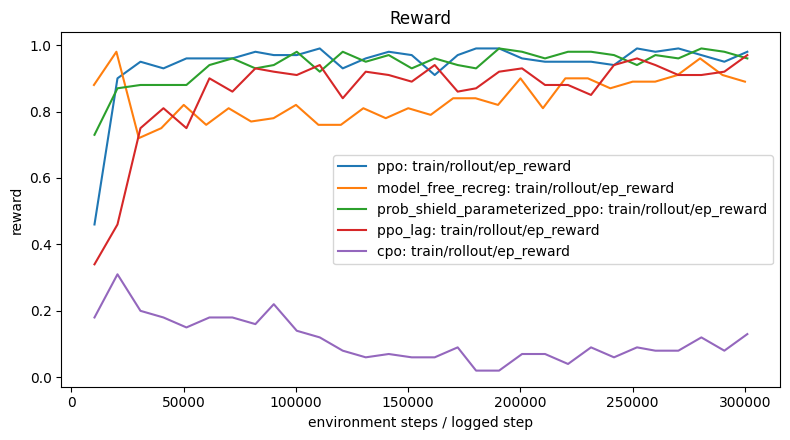

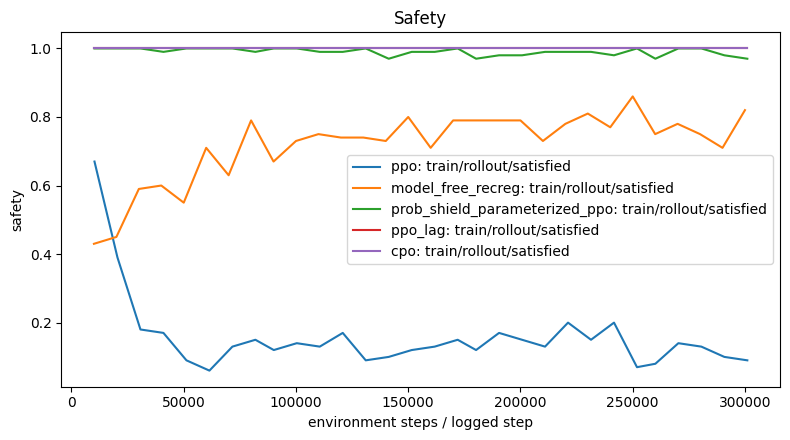

In [53]:
def plot_metric(metric_name: str):
    plt.figure(figsize=(8, 4.5))
    plotted = False
    for label, tags in selected.items():
        tag = tags[metric_name]
        if tag is None:
            continue
        arr = run_scalars[label][tag]
        if len(arr["step"]) == 0:
            continue
        plt.plot(arr["step"], arr["value"], label=f"{label}: {tag}")
        plotted = True
    plt.xlabel("environment steps / logged step")
    plt.ylabel(metric_name)
    plt.title(metric_name.capitalize())
    if plotted:
        plt.legend()
    else:
        print(f"No {metric_name} tags were found. Inspect the printed tag lists above and update candidates/selected tags.")
    plt.tight_layout()
    plt.show()

plot_metric("reward")
plot_metric("safety")

**Talking point.** The shielded policy receives an augmented action interface: the policy proposes primary/fallback actions and a continuous allocation of risk budget. The wrapper projects this proposal back into the safe set before stepping the environment, so the safety semantics are enforced at the interface rather than only through a penalty.